<a href="https://colab.research.google.com/github/JoseLLoredoHdz/mineria/blob/main/Liga_MX_jornada_17_178446.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


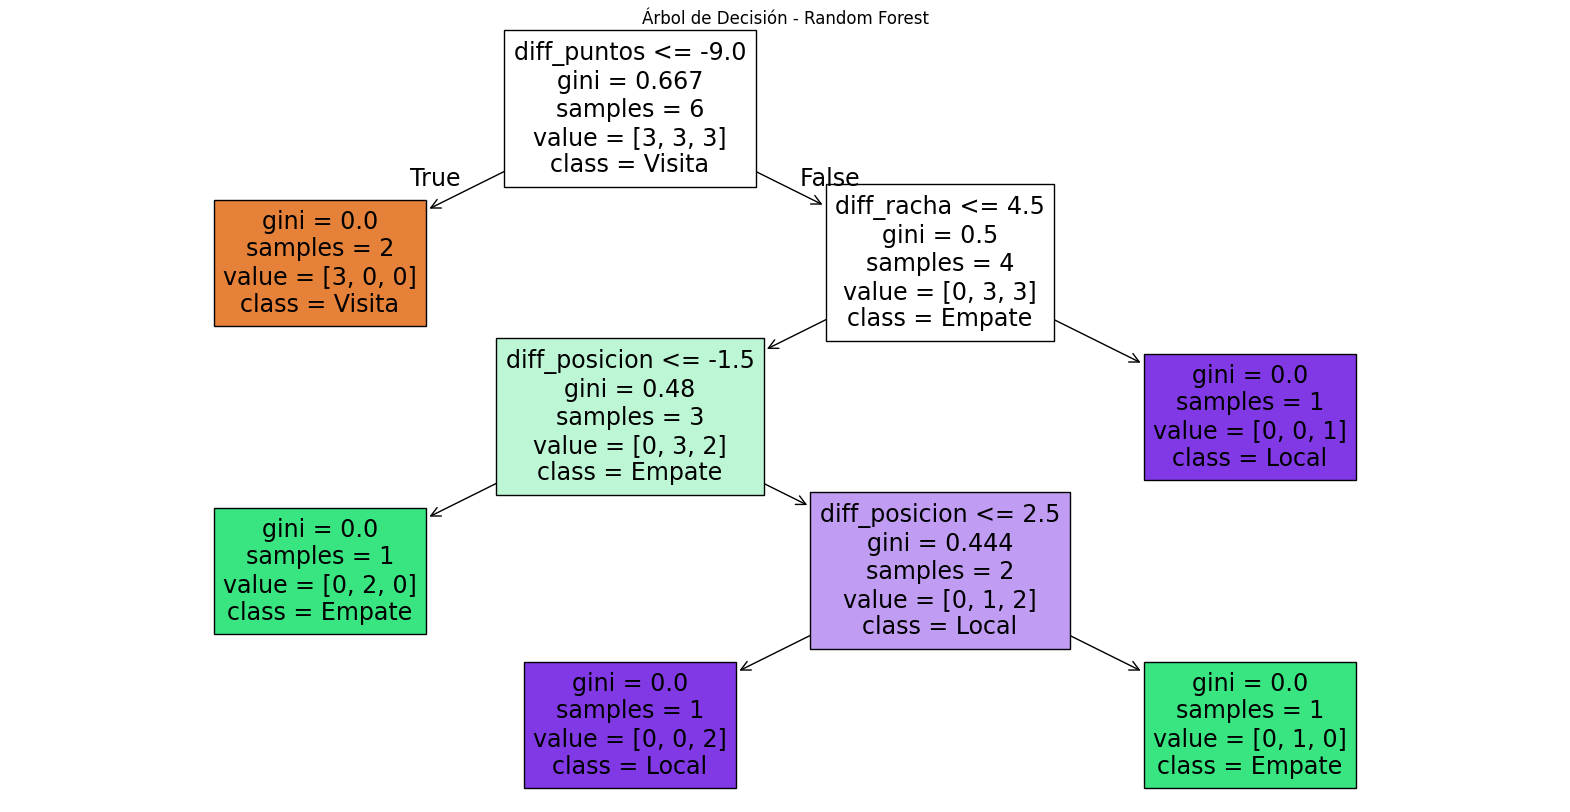


--- RESULTADOS PREDICHOS JORNADA 17 ---
                          Partido resultado_predicho
0             Puebla vs Querétaro           Empatan 
1                Pachuca vs Pumas    Gana visitante 
2              Tigres vs Mazatlán           Empatan 
3                  Toluca vs León           Empatan 
4               Chivas vs Tijuana        Gana local 
5                América vs Atlas        Gana local 
6  FC Juárez vs Atlético San Luis           Empatan 
7             Santos vs Monterrey    Gana visitante 
8             Cruz Azul vs Necaxa           Empatan 


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Conexión con Google Drive
drive.mount('/content/drive')

# dataset base de entrenamiento
path = '/content/drive/MyDrive/Mineria/parcial3/dataset_liga_mx_jornadas_13_14_15_base.csv'
df = pd.read_csv(path)

# Selección de features
features = ['diff_puntos','diff_racha','diff_posicion']
X = df[features]
y = df['resultado']

# Entrenamiento del Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X, y)

# Visualización del árbol
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0], feature_names=features, class_names=['Visita','Empate','Local'], filled=True)
plt.title("Árbol de Decisión - Random Forest")
plt.show()

# --- PREDICCIONES JORNADA 17 ---
# Datos matemáticos actualizados tras los resultados de la J16
data_j17 = {
    'Partido': [
        'Puebla vs Querétaro',
        'Pachuca vs Pumas',
        'Tigres vs Mazatlán',
        'Toluca vs León',
        'Chivas vs Tijuana',
        'América vs Atlas',
        'FC Juárez vs Atlético San Luis',
        'Santos vs Monterrey',
        'Cruz Azul vs Necaxa'
    ],
    # diff = Local - Visitante (Actualizado post-J16)
    'diff_puntos': [-6, -18, 10, 6, 18, 2, 4, -23, 12],
    'diff_racha': [-3, -4, 2, 1, 5, 1, 3, -5, 2],
    'diff_posicion': [5, 12, -8, -3, -11, -1, -2, 14, -7]
}

df_j17 = pd.DataFrame(data_j17)
X_j17 = df_j17[features]

# Ejecución de predicción
predicciones_j17 = rf.predict(X_j17)

# Mapeo de etiquetas
map_resultados = {0: 'Gana visitante ', 1: 'Empatan ', 2: 'Gana local '}
df_j17['resultado_predicho'] = [map_resultados[p] for p in predicciones_j17]

print("\n--- RESULTADOS PREDICHOS JORNADA 17 ---")
pd.set_option('display.max_colwidth', None)
print(df_j17[['Partido', 'resultado_predicho']])

## Ética y uso responsable
# Este modelo es educativo. No debe usarse para apuestas ni decisiones financieras.